In [1]:
from superfv import HydroSolverOutput

import matplotlib.pyplot as plt


In [2]:
base_path = "/scratch/gpfs/jp7427/superfv/sinus-2d-profiling/"

def get_timing(name, N, cupy, nsteps):
    path = base_path
    if cupy:
        path += "cupy/"
    path += f"{name}/N_{N}"
    sim = HydroSolverOutput(path)

    if len(sim.step_history[2:]) != nsteps - 1:
        raise ValueError(f"Got unexpected number of steps: {len(sim.step_history[1:])}")

    nsteps = 0
    runtime = 0.0
    for s in sim.step_history[2:]:
        nsteps += 1
        runtime += s.timer["take_step"].cum_time

    update_rate = nsteps * sim.mesh.nx * sim.mesh.ny * sim.mesh.nz / runtime
    return update_rate

In [3]:
N_list = [32, 64, 128, 256, 512, 1024, 2048, 3072]
nsteps = 11

def plot_timing(ax, name, cupy, **kwargs):
    rate_list = []
    N_list_for_plotting = []
    for N in N_list:
        try:
            rate_list.append(get_timing(name, N, cupy, nsteps))
            N_list_for_plotting.append(N)
        except FileNotFoundError:
            pass
    ax.plot(N_list_for_plotting, rate_list, **kwargs)

/home/jp7427/Desktop/superfv/superfv/mesh.py:268: UserWarning: Cupy is not available. Falling back to NumPy.
  warnings.warn("Cupy is not available. Falling back to NumPy.")


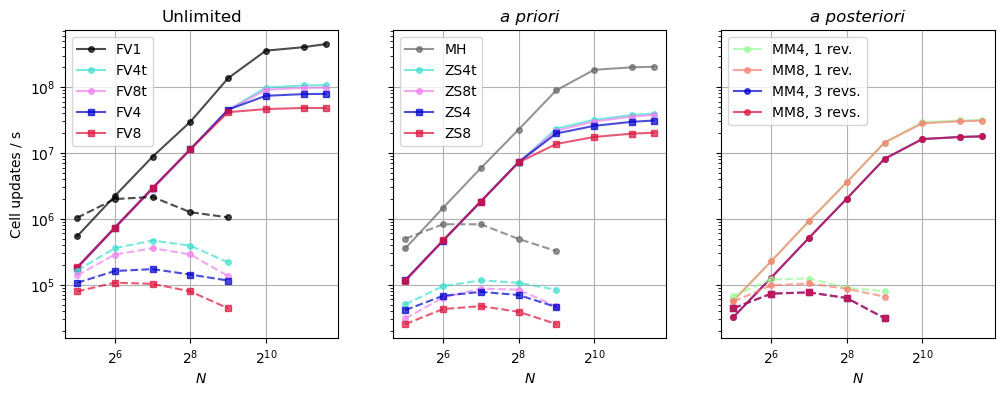

In [9]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 4))
axs[0].set_xscale("log", base=2)
axs[0].set_yscale("log")

common = dict(markersize=4, alpha=0.7)

axs[0].set_title("Unlimited")
plot_timing(axs[0], "p0", True, label="FV1", marker="o", color="black", **common)
plot_timing(axs[0], "p3", True, label="FV4t", marker="o", color="turquoise", **common)
plot_timing(axs[0], "p7", True, label="FV8t", marker="o", color="violet", **common)
plot_timing(axs[0], "p3_GL", True, label="FV4", marker="s", color="mediumblue", **common)
plot_timing(axs[0], "p7_GL", True, label="FV8", marker="s", color="crimson", **common)

plot_timing(axs[0], "p0", False, linestyle="--", marker="o", color="black", **common)
plot_timing(axs[0], "p3", False, linestyle="--", marker="o", color="turquoise", **common)
plot_timing(axs[0], "p7", False, linestyle="--", marker="o", color="violet", **common)
plot_timing(axs[0], "p3_GL", False, linestyle="--", marker="s", color="mediumblue", **common)
plot_timing(axs[0], "p7_GL", False, linestyle="--", marker="s", color="crimson", **common)

axs[1].set_title("a priori", style='italic')
plot_timing(axs[1], "MUSCL-Hancock", nsteps, label="MH", marker="o", color="dimgrey", **common)
plot_timing(axs[1], "ZS3t", nsteps, label="ZS4t", marker="o", color="turquoise", **common)
plot_timing(axs[1], "ZS7t", nsteps, label="ZS8t", marker="o", color="violet", **common)
plot_timing(axs[1], "ZS3", nsteps, label="ZS4", marker="s", color="mediumblue", **common)
plot_timing(axs[1], "ZS7", nsteps, label="ZS8", marker="s", color="crimson", **common)

plot_timing(axs[1], "MUSCL-Hancock", False, linestyle="--", marker="o", color="dimgrey", **common)
plot_timing(axs[1], "ZS3t", False, linestyle="--", marker="o", color="turquoise", **common)
plot_timing(axs[1], "ZS7t", False, linestyle="--", marker="o", color="violet", **common)
plot_timing(axs[1], "ZS3", False, linestyle="--", marker="s", color="mediumblue", **common)
plot_timing(axs[1], "ZS7", False, linestyle="--", marker="s", color="crimson", **common)

axs[2].set_title("a posteriori", style='italic')
plot_timing(axs[2], "MM3_1rev_rtol_0", nsteps, label="MM4, 1 rev.", marker="o", color="palegreen", **common)
plot_timing(axs[2], "MM7_1rev_rtol_0", nsteps, label="MM8, 1 rev.", marker="o", color="salmon", **common)
plot_timing(axs[2], "MM3_3revs_rtol_0", nsteps, label="MM4, 3 revs.", marker="o", color="mediumblue", **common)
plot_timing(axs[2], "MM3_3revs_rtol_0", nsteps, label="MM8, 3 revs.", marker="o", color="crimson", **common)

plot_timing(axs[2], "MM3_1rev_rtol_0", False, linestyle="--", marker="o", color="palegreen", **common)
plot_timing(axs[2], "MM7_1rev_rtol_0", False, linestyle="--", marker="o", color="salmon", **common)
plot_timing(axs[2], "MM3_3revs_rtol_0", False, linestyle="--", marker="s", color="mediumblue", **common)
plot_timing(axs[2], "MM3_3revs_rtol_0", False, linestyle="--", marker="s", color="crimson", **common)

axs[0].set_ylabel("Cell updates / s")
for ax in axs:
    ax.legend()
    ax.grid()
    ax.set_xlabel(r"$N$")

fig.savefig("roofline.pdf", bbox_inches="tight")